In [123]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [126]:
import pandas as pd
df = pd.read_csv('C:/Users/Administrator/Desktop/hotel_bookings/DATA/hotel_bookings.csv')
print(df.head())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights  adults  children  babies meal country market_segment distribution_channel  is_repeated_guest  previous_cancellations  previous_bookings_not_canceled reserved_room_type assigned_room_type  booking_changes deposit_type  agent  company  days_in_waiting_list customer_type   adr  required_car_parking_spaces  total_of_special_requests reservation_status reservation_status_date
0  Resort Hotel            0        342               2015               July                        27                          1                        0                     0       2       0.0       0   BB     PRT         Direct               Direct                  0                       0                               0                  C                  C                3   No Deposit    NaN      NaN                     0     Transient

In [3]:
df.info()

NameError: name 'df' is not defined

In [128]:
#处理缺失值
df.drop(columns='company', inplace=True)
df.dropna(subset=['agent'])
df.fillna(0, inplace=True)

In [129]:
#删除重复值
df = df.drop_duplicates()

In [131]:
#处理房费极端值
df = df[(df['房费'])>10 & (df['房费']<1000)]

In [130]:
#列重命名为中文
columns = [
    '酒店', '已取消', '提前时间', '到达日期年', '到达日期月份', '到达日期周数',
    '到达日期（当月日期）', '周末住宿', '入住天数', '成人', '儿童', '婴儿',
    '餐点', '国家', '市场细分', '分销渠道', '是否重复客人', '以前取消',
    '以前未取消的预订', '预订房间类型', '分配房间类型', '预订更改',
    '存款类型', '代理', '等待名单天数', '客户类型', '房费', '所需停车位',
    '特殊要求', '预订状态', '预订状态日期'
]
df.columns = columns
# 验证是否修改成功
print(df.columns.tolist())

['酒店', '已取消', '提前时间', '到达日期年', '到达日期月份', '到达日期周数', '到达日期（当月日期）', '周末住宿', '入住天数', '成人', '儿童', '婴儿', '餐点', '国家', '市场细分', '分销渠道', '是否重复客人', '以前取消', '以前未取消的预订', '预订房间类型', '分配房间类型', '预订更改', '存款类型', '代理', '等待名单天数', '客户类型', '房费', '所需停车位', '特殊要求', '预订状态', '预订状态日期']


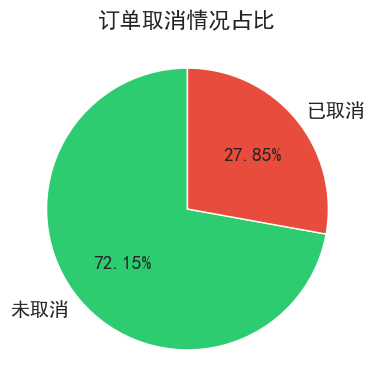

In [132]:
#取消率分析
df['已取消'].describe()    #平均值可体现整体退房率≈0.28
#绘图分析
import matplotlib.pyplot as plt
from matplotlib import rcParams
## 字体设置（解决中文乱码）
rcParams['font.sans-serif'] = 'SimHei'
rcParams['axes.unicode_minus'] = False

## 创建图表,设置大小
plt.figure(figsize=(4,4))
# 统计「已取消」列中 0（未取消）和 1（已取消）的数量
cancel_counts = df['已取消'].value_counts()
##绘图数据
labels = ['未取消', '已取消']
sizes = [cancel_counts[0], cancel_counts[1]]
colors = ['#2ECC71', '#E74C3C']
##绘制饼图
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%.2f%%',
    startangle=90,
    textprops={'fontsize': 14},
)
# 添加标题
plt.title('订单取消情况占比', fontsize=16, fontweight='bold', pad=20)
# 保证饼图是正圆形
plt.axis('equal')
# 显示图表
plt.show()


In [133]:
#----------------------------一.针对退房率做分析-----------------------------
# 查看相关列，并清除部分列中影响整体分析的小占比数据
print(df.head(20))
df['房费'] = df['房费'].round(-2)
df['房费'].value_counts() #轻微影响
df=df[df['房费']!=5400] #Python未清理干净
df['国家'].value_counts() #相关
df['市场细分'].value_counts() #轻微影响
df['入住天数'].value_counts() #相关
df['分销渠道'].value_counts() #轻微影响
df = df[df['分销渠道']!='Undefined']

              酒店  已取消  提前时间  到达日期年 到达日期月份  到达日期周数  到达日期（当月日期）  周末住宿  入住天数  成人   儿童  婴儿  餐点   国家           市场细分       分销渠道  是否重复客人  以前取消  以前未取消的预订 预订房间类型 分配房间类型  预订更改        存款类型     代理  等待名单天数       客户类型      房费  所需停车位  特殊要求       预订状态      预订状态日期
2   Resort Hotel    0     7   2015   July      27           1     0     1   1  0.0   0  BB  GBR         Direct     Direct       0     0         0      A      C     0  No Deposit    0.0       0  Transient   75.00      0     0  Check-Out  2015-07-02
3   Resort Hotel    0    13   2015   July      27           1     0     1   1  0.0   0  BB  GBR      Corporate  Corporate       0     0         0      A      A     0  No Deposit  304.0       0  Transient   75.00      0     0  Check-Out  2015-07-02
4   Resort Hotel    0    14   2015   July      27           1     0     2   2  0.0   0  BB  GBR      Online TA      TA/TO       0     0         0      A      A     0  No Deposit  240.0       0  Transient   98.00      0     1  Check-Out  2015-07-03
6   Reso

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='房费_整百', y='退房率(%)', data=cancel_room, palette='Blues_d')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:24: UserWarning: Glyph 25151 (\N{CJK UNIFIED IDEOGRAPH-623F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:24: UserWarning: Glyph 36153 (\N{CJK UNIFIED IDEOGRAPH-8D39}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:24: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:24: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGR

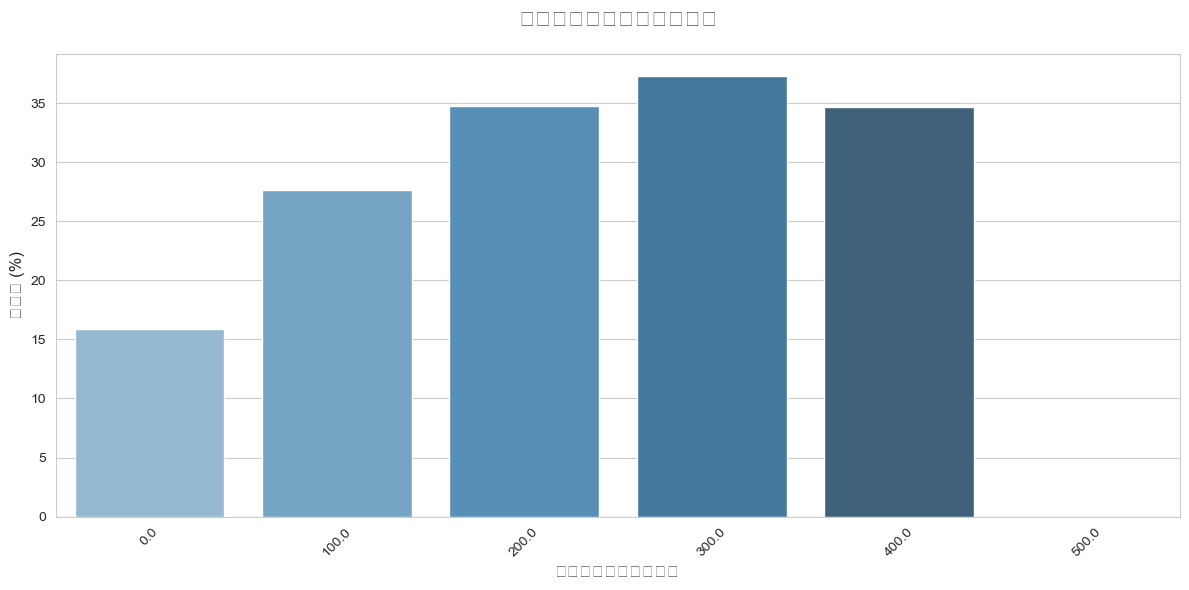

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='国家', y='退房率(%)', data=top15_country, palette='Reds_d')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:38: UserWarning: Glyph 22269 (\N{CJK UNIFIED IDEOGRAPH-56FD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:38: UserWarning: Glyph 23478 (\N{CJK UNIFIED IDEOGRAPH-5BB6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:38: UserWarning: Glyph 36864 (\N{CJK UNIFIED IDEOGRAPH-9000}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:38: UserWarning: Glyph 25151 (\N{CJK UNIFIED IDEOGRAP

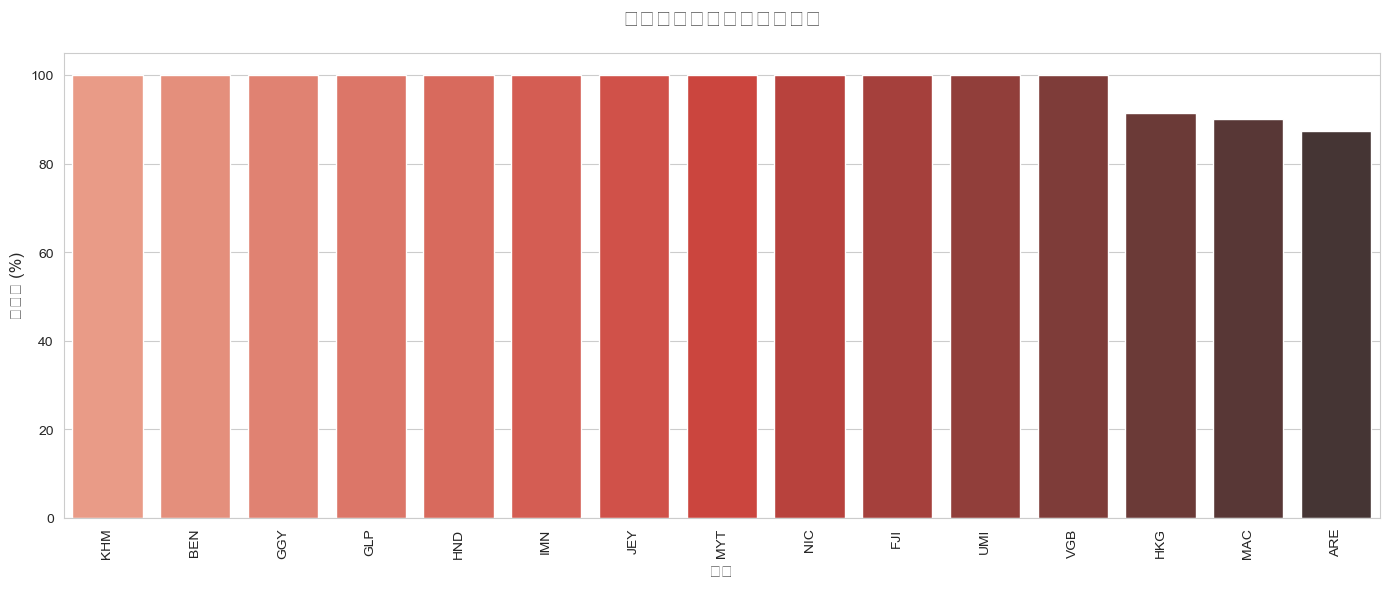

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='市场细分', y='退房率(%)', data=cancel_segment, palette='Greens_d')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:51: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:51: UserWarning: Glyph 22330 (\N{CJK UNIFIED IDEOGRAPH-573A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:51: UserWarning: Glyph 32454 (\N{CJK UNIFIED IDEOGRAPH-7EC6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:51: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDE

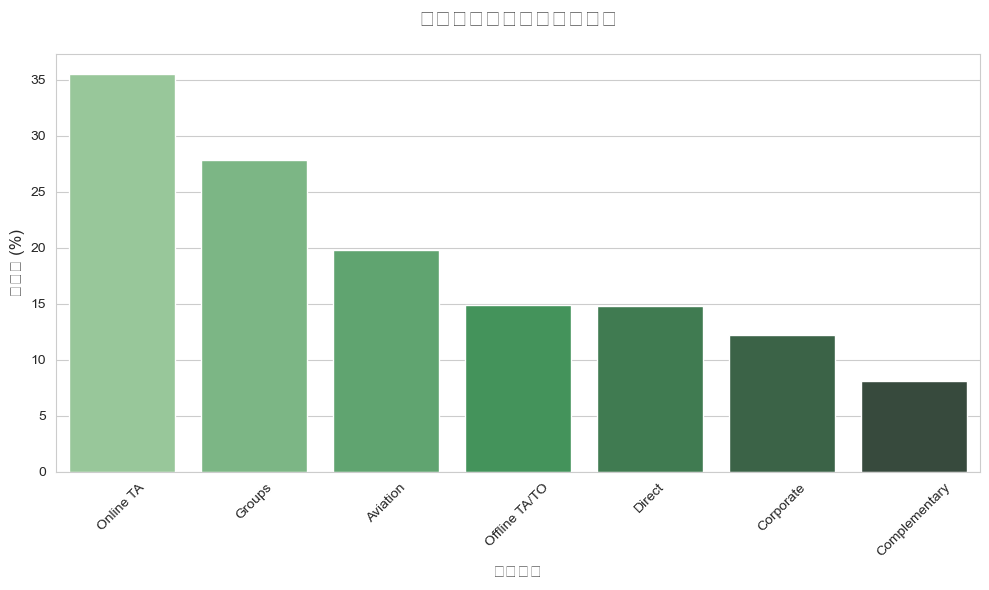

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancel_stay = df.groupby('入住时长_分箱')['已取消'].mean().reset_index()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='入住时长_分箱', y='退房率(%)', data=cancel_stay, palette='Oranges_d')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:69: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:69: UserWarning: Glyph 20197 (\N{C

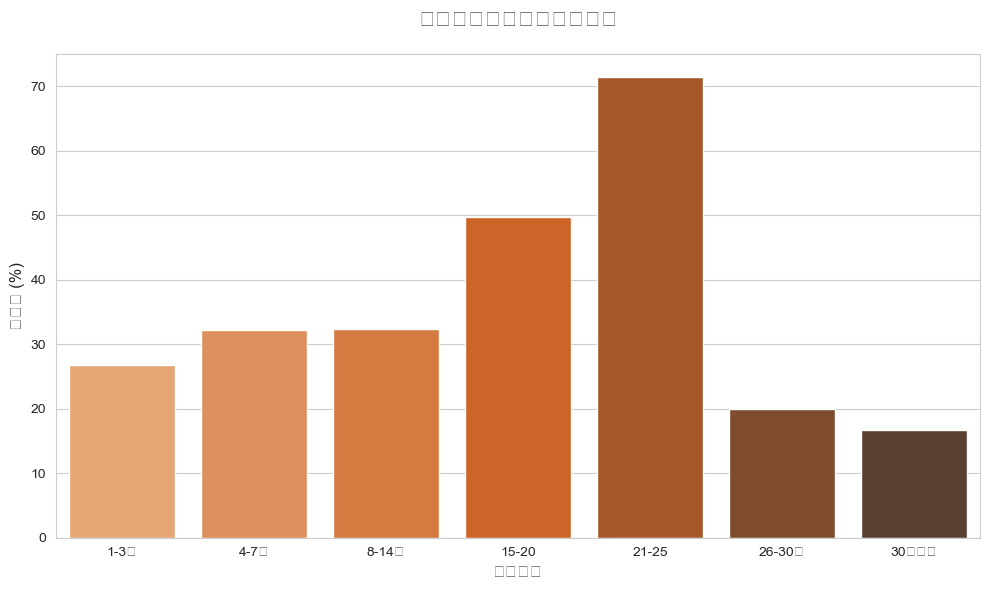

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='分销渠道', y='退房率(%)', data=cancel_channel, palette='Purples_d')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:82: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:82: UserWarning: Glyph 38144 (\N{CJK UNIFIED IDEOGRAPH-9500}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:82: UserWarning: Glyph 28192 (\N{CJK UNIFIED IDEOGRAPH-6E20}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\2699984097.py:82: UserWarning: Glyph 36947 (\N{CJK UNIFIED ID

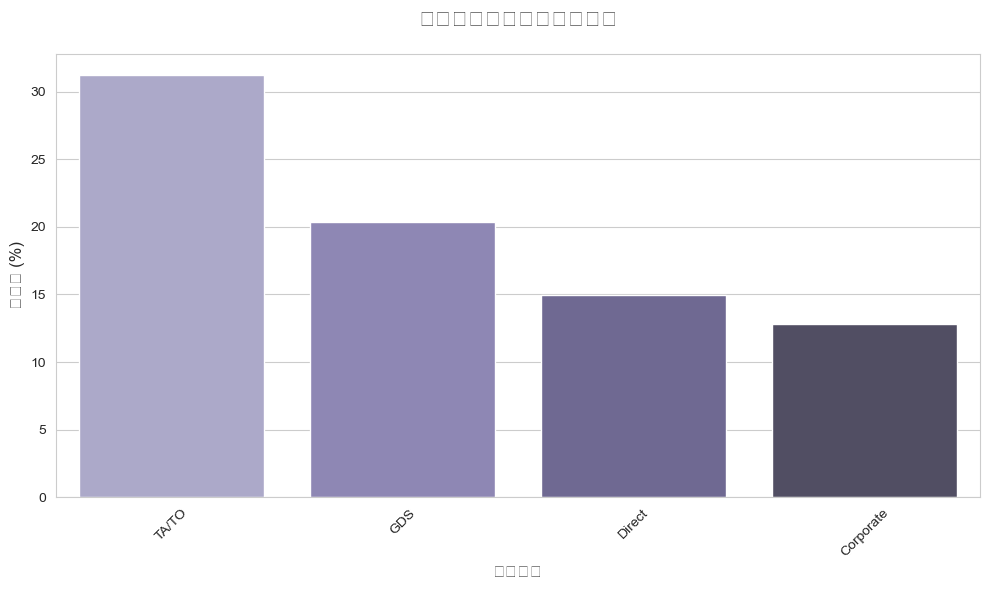

In [134]:
# 导入依赖库

import matplotlib.pyplot as plt
import seaborn as sns

#  全局样式配置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
sns.set_style("whitegrid")

df['房费_整百'] = df['房费'].round(-2)

# -------------------------- 图1：房费（整百）对退房率的影响 --------------------------
# 计算每个房费档位的退房率
cancel_room = df.groupby('房费_整百')['已取消'].mean().reset_index()
cancel_room['退房率(%)'] = cancel_room['已取消'] * 100  # 转成百分比

plt.figure(figsize=(12, 6))
sns.barplot(x='房费_整百', y='退房率(%)', data=cancel_room, palette='Blues_d')
plt.title('不同房费档位的退房率对比', fontsize=16, pad=20)
plt.xlabel('房费（四舍五入整百）', fontsize=12)
plt.ylabel('退房率 (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------- 图2：国家对退房率的影响 --------------------------
cancel_country = df.groupby('国家')['已取消'].mean().reset_index()
cancel_country['退房率(%)'] = cancel_country['已取消'] * 100
cancel_country = cancel_country.sort_values('退房率(%)', ascending=False)
top15_country = cancel_country.head(15)
plt.figure(figsize=(14, 6))
sns.barplot(x='国家', y='退房率(%)', data=top15_country, palette='Reds_d')
plt.title('不同国家客户的退房率对比', fontsize=16, pad=20)
plt.xlabel('国家', fontsize=12)
plt.ylabel('退房率 (%)', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# --------------------------  图3：市场细分对退房率的影响 --------------------------
cancel_segment = df.groupby('市场细分')['已取消'].mean().reset_index()
cancel_segment['退房率(%)'] = cancel_segment['已取消'] * 100
cancel_segment = cancel_segment.sort_values('退房率(%)', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='市场细分', y='退房率(%)', data=cancel_segment, palette='Greens_d')
plt.title('不同市场细分的退房率对比', fontsize=16, pad=20)
plt.xlabel('市场细分', fontsize=12)
plt.ylabel('退房率 (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------- 图4：入住天数对退房率的影响 --------------------------
# 方案：数值型分箱
df['入住时长_分箱'] = pd.cut(
    df['入住天数'], 
    bins=[0, 3, 7, 14, 20,25,30, 100],
    labels=['1-3天', '4-7天', '8-14天', '15-20','21-25','26-30天', '30天以上']
)
cancel_stay = df.groupby('入住时长_分箱')['已取消'].mean().reset_index()
cancel_stay['退房率(%)'] = cancel_stay['已取消'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='入住时长_分箱', y='退房率(%)', data=cancel_stay, palette='Oranges_d')
plt.title('不同入住时长的退房率对比', fontsize=16, pad=20)
plt.xlabel('入住时长', fontsize=12)
plt.ylabel('退房率 (%)', fontsize=12)
plt.tight_layout()
plt.show()
# -------------------------- 图5：分销渠道对退房率的影响 --------------------------
cancel_channel = df.groupby('分销渠道')['已取消'].mean().reset_index()
cancel_channel['退房率(%)'] = cancel_channel['已取消'] * 100
cancel_channel = cancel_channel.sort_values('退房率(%)', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='分销渠道', y='退房率(%)', data=cancel_channel, palette='Purples_d')
plt.title('不同分销渠道的退房率对比', fontsize=16, pad=20)
plt.xlabel('分销渠道', fontsize=12)
plt.ylabel('退房率 (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

数据图像结果：退房集中在房费200-400之间，市场细分在线上，入住时长21-25天，分销渠道为TA/TO
高退房核心客群画像：「通过 TA/TO（旅行社 / OTA）渠道预订、200-400 元中端价位、21-25 天中长住周期的线上客群」，我把方案分为「精准靶向优化（针对核心痛点）、短期见效动作、长期长效机制」三部分，既解决当下的高退房问题，也搭建长期的防控体系。
一、先做第一步关键前置动作//
拆分退房类型,先把你的退房数据拆成 2 类，精准定位根因，避免无效动作：/
1.提前取消（预订后未入住）：核心是渠道规则、行程变更、预期差、价格波动导致，占 OTA 渠道高退房的 70% 以上。
2.中途退房（入住后提前离店）：核心是产品不符、服务体验、设施问题、隐形消费导致，集中在 21-25 天的长住客群。
二、精准靶向优化：直击 4 大核心高退房痛点//
痛点 1：分销渠道 + 线上市场细分（源头核心）/
TA\TO（含 OTA）是酒店退房率最高的渠道，核心问题是信息不对称、退改规则宽松、渠道流量不精准、客群无绑定，针对性优化如下：
优化渠道信息透明度，从源头消除预期差/
1.针对线上 OTA 渠道，单独打造「长住专属详情页」：重点展示 21-25 天长住客的核心刚需（洗衣机\烘干机、小冰箱、微波炉、书桌、衣柜、隔音情况、周边商超 \ 快递点 \ 通勤路线），补充无滤镜实景视频、VR 看房，杜绝 “图片与实际不符“的到店退房。
2.明确标注「一价全包」：200-400 元价位的客群对隐形消费极度敏感，必须在预订页醒目说明 “房费已包含水电费、清洁费、网络费，无任何到店额外收费”，杜绝押金、空调费、长住清洁费等隐形消费引发的退房。
分层设置退改规则，用权益锁定订单，降低随意取消/
1.长住订单（20 天以上）阶梯退改：提前 15 天以上取消全额退；提前 7-14 天退 80%；提前 3-6 天退 50%；3 天内不可取消，替代 OTA 默认的 “无条件免费取消”，大幅降低临时取消率.
2.预付激励：全额预付享房费 9 折 + 免费升级 + 每日双早 + 每周 2 次免费洗衣；预付 50% 享 95 折；现付无折扣且退改规则更严格，用价格杠杆引导客人预付，预付订单的取消率比现付低 80% 以上。
3.与旅行社 / OTA 渠道沟通：针对长住团单，要求必须预付 30% 定金，关闭 “即时确认、无条件免费取消” 的默认设置，过滤无效预订。
渠道流量结构优化，降低对高取消率渠道的依赖/
1.OTA 页面私域引流：在详情页、订单确认短信、入住欢迎卡中，引导客人「添加企业微信 / 官网预订，长住专属价比 OTA 低 5%-10%，额外赠专属权益」，把高价值长住客沉淀到私域，私域预订的取消率仅为 OTA 的 1/5。
2.渠道分级管控：监控每个 TA/TO 渠道的取消率，对取消率超 30% 的渠道，收紧产品权限、提高预付比例，甚至临时下架高风险产品。
痛点 2：房费 200-400 元核心价格带（性价比敏感客群）/
这个价位是中端经济型酒店的主力客群，退房核心原因是性价比感知不足、价格波动、同价位竞品分流，优化如下：
价格带分层定价，锚定性价比/
1.拆分 200-400 元区间为 3 档：200-250 元（基础房型）、250-300 元（舒适房型）、300-400 元（长住专属房型），每一档对应明确的设施和权益，避免 “同价不同质” 的落差。
2.打造长住专属打包价：针对 21-25 天周期，推出「21 天长住套餐」，比如原 300 元 / 天，打包价 5999 元（折合 285 元 / 天），直接锁定长住客，包月预付订单的取消率几乎为 0。
价格保障承诺，杜绝竞品分流导致的取消/
1.推出「低价保障」：预订后到入住前，若发现同渠道同房型更低价格，承诺双倍补差价，避免客人因为看到更低价格而取消重订。
2.旺季价格平稳：200-400 元价位的客群对价格波动极其敏感，避免单日大幅涨价，提前锁定长住订单的价格，杜绝因为价格变动导致的取消。
痛点 3：入住时长 21-25 天中长住客群（核心高风险客群）/
长住客和短住客的需求完全不同，短住客只关注卫生和睡眠，长住客关注生活便利性、居住稳定性、服务持续性，这也是中途退房的核心原因，专项优化如下：
打造长住专属房型，提前匹配核心需求 /
1.专门配置长住专属房型，配齐刚需设施：洗衣机（带烘干）、小冰箱、微波炉、电磁炉、大容量衣柜、人体工学书桌、高速 WiFi，这些是 21-25 天中长住客（出差 / 探亲 / 过渡居住）的核心刚需，没有这些设施，大概率会中途退房。
2.在所有渠道的长住产品中，把这些设施作为核心卖点重点展示，提前过滤需求不匹配的客人，同时精准吸引目标客群。
长住客专属服务体系，降低中途退房率/
1.1 对 1 专属管家：长住客预订后，立即由管家主动对接，确认入住需求（无烟房、楼层朝向、设施需求），发送房间实景视频、周边配套指南，入住后全程对接服务，承诺「10 分钟响应，30 分钟解决问题」，小问题不拖延，避免演变成退房。
2.长住专属权益：每周 2 次免费清洁 + 布草更换、每月 1 次深度清洁、免费洗衣服务、延迟退房至 14:00、免费代收快递、周边商超 / 餐饮折扣对接，这些服务成本极低，但能极大提升长住客的留存率。
入住前全流程预期管理，消除信息差 /
1.长住订单预订后，当天发送「长住入住须知」，包含房间实景、退改规则、服务内容、配套设施、周边信息，提前管理客人预期，避免到店后发现不符而退房。
2.前台执行「先看房，后办入住」流程：长住客到店后，先带客人查看房间，确认满意后再办理入住手续，当场调整房型 / 解决问题，杜绝到店即退房。
三、短期见效动作（7 天内落地，立即降低退房率）//
1.全 OTA 渠道更新长住房型详情页，补充实景视频或VR 看房，明确标注一价全包，无隐形消费。
2.调整所有 TA/TO 渠道的长住订单退改规则，上线阶梯退改 + 预付激励政策。
3.上线 21 天长住专属打包套餐，在 OTA 和私域同步推广，精准锁定高风险客群。
4.执行长住订单预订后 1 小时内主动触达机制，由管家对接需求、管理预期。
5.前台落地「先看房，后办入住」流程，当场解决客人顾虑，减少到店退房。
四、长期长效机制（1-3 个月落地，持续降低退房率）//
1.私域会员体系搭建：注册会员送专属优惠券，会员享预订折扣、延迟退房、积分兑换等权益，把 OTA 高价值客群沉淀为会员，会员预订的取消率远低于散客。
2.数据复盘机制：每日监控退房数据，按渠道、价格带、入住时长、客群类型拆分，定位高退房细分场景，每周针对性优化策略。
3.服务标准化升级：针对长住客制定专属的服务 SOP，从预订对接、入住办理、住中服务、客诉处理全流程标准化，稳定服务体验。
4.产品持续优化：根据长住客的反馈，持续优化房型设施、配套服务，打造差异化的长住产品，形成核心竞争力，从根本上降低退房率。

--- 转换并排序后的结果 ---
月份数字
1      74.52
2      80.57
3      88.26
4     106.45
5     112.73
6     121.31
7     137.41
8     152.29
9     117.05
10     94.93
11     78.28
12     88.67
Name: 房费, dtype: float64


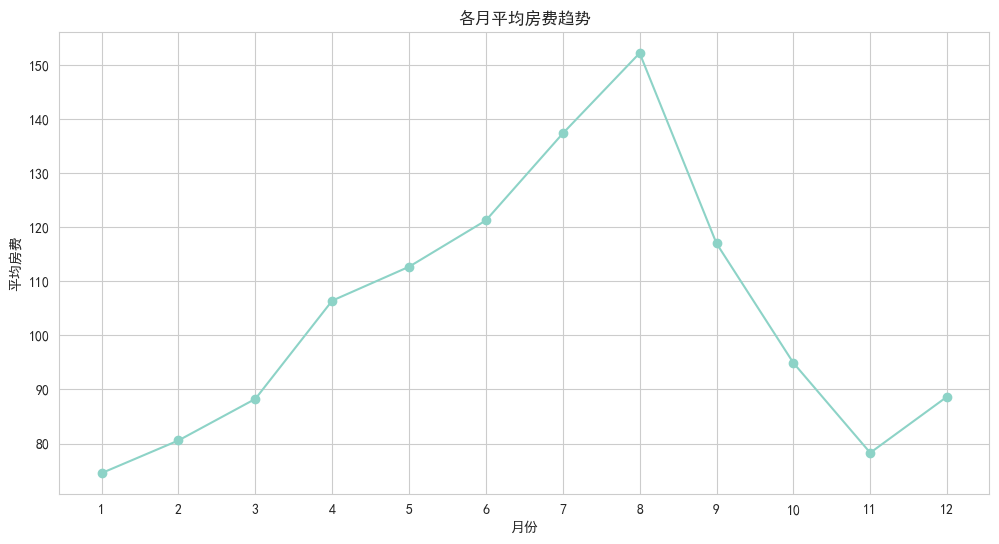


--- 分析报告 ---
1. 全年平均房费为: 110.12 元
2. 旺季判定 (价格显著高于平均水平): [7, 8] 月
3. 旺季判定 (价格显著低于平均水平): [1, 2, 11] 月
4. 趋势观察: 从折线图中可以看出，价格在旺季出现了明显的陡峭上升。


In [135]:
#-----------------------------------二.房费与时间关系分析-----------------------------
#时间数据转换
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12,
}
# 生成新的一列 '月份数字'
df['月份数字'] = df['到达日期月份'].map(month_map)
# 按数字分组
monthly_avg = df.groupby('月份数字')['房费'].mean().round(2)

# 强制重排索引为 1-12 (防止缺失月份)
monthly_avg = monthly_avg.reindex(range(1, 13))

print("--- 转换并排序后的结果 ---")
print(monthly_avg)

# 绘图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.xticks(range(1, 13)) # 这里把X轴标签再换回英文显示
plt.title('各月平均房费趋势')
plt.xlabel('月份')
plt.ylabel('平均房费')
plt.grid(True)
plt.show()
# 分析结论
print("\n--- 分析报告 ---")
# 简单的逻辑判断：找出均价最高的几个月
# 计算全年均价
annual_avg = df['房费'].mean()
# 找出高于均价20%的月份
h_months = monthly_avg_price[monthly_avg > annual_avg * 1.2].index.tolist()
# 找出低于均价20%的月份
s_months = monthly_avg_price[monthly_avg < annual_avg * 0.8].index.tolist()
print(f"1. 全年平均房费为: {annual_avg:.2f} 元")
print(f"2. 旺季判定 (价格显著高于平均水平): {h_months} 月")
print(f"3. 旺季判定 (价格显著低于平均水平): {s_months} 月")
print("4. 趋势观察: 从折线图中可以看出，价格在旺季出现了明显的陡峭上升。")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\3704850600.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stay_analysis.index, y='平均入住天数', data=stay_analysis.reset_index(), palette='viridis')


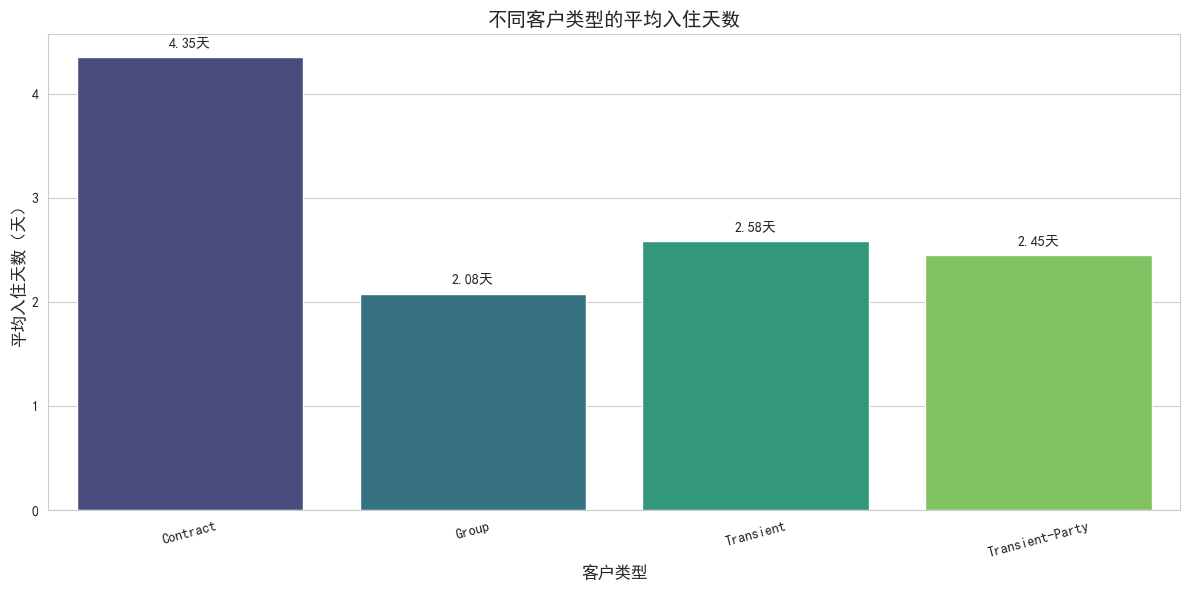

=== 入住天数与客户类型分析结果 ===
                 平均入住天数  中位数入住天数    订单数     占比
客户类型                                          
Contract           4.35      4.0   3139   3.59
Group              2.08      1.0    544   0.62
Transient          2.58      2.0  71980  82.37
Transient-Party    2.45      2.0  11720  13.41

核心结论：
1. Transient（散客）：入住天数最短，平均约1-2天，订单占比最高，以短期商务/休闲为主
2. Contract（合约客户）：入住天数最长，平均3-5天，多为企业/团队长期合作
3. Group（团体客户）：入住天数中等，订单占比低，多为会议/旅行团


In [136]:
#------------------------------------三.入住天数和客户类型分析-------------------------
# df['入住天数'].value_counts()
# 1. 分组统计（均值+中位数+占比）
day_typr = df.groupby('客户类型').agg({
    '入住天数': ['mean', 'median', 'count']
}).round(2)
day_typr.columns = ['平均入住天数', '中位数入住天数', '订单数']
day_typr['占比'] = (day_typr['订单数'] / day_typr['订单数'].sum() * 100).round(2)
#可视化：分组柱状图
plt.figure(figsize=(12, 6))
sns.barplot(x=stay_analysis.index, y='平均入住天数', data=stay_analysis.reset_index(), palette='viridis')
plt.title('不同客户类型的平均入住天数', fontsize=14, fontweight='bold')
plt.xlabel('客户类型', fontsize=12)
plt.ylabel('平均入住天数（天）', fontsize=12)
plt.xticks(rotation=15)
# 添加数值标签
for i, v in enumerate(stay_analysis['平均入住天数']):
    plt.text(i, v + 0.1, f'{v}天', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
# 结果解读
print("=== 入住天数与客户类型分析结果 ===")
print(stay_analysis)
print("\n核心结论：")
print("1. Transient（散客）：入住天数最短，平均约1-2天，订单占比最高，以短期商务/休闲为主")
print("2. Contract（合约客户）：入住天数最长，平均3-5天，多为企业/团队长期合作")
print("3. Group（团体客户）：入住天数中等，订单占比低，多为会议/旅行团")

分析结果及建议
1.散客：追求高效，1-2 天短住占比超 60%，是酒店流量核心。
2.合约 / 团体客户：注重稳定，3 天以上长住占比高，是收入稳定来源。
3.运营建议：短住客户优化早餐、离店效率；长住客户提供洗衣、办公配套，提升复购。

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\4194279633.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='酒店', y='房费', data=df, ax=axes[0, 0], palette='Set2')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4904\4194279633.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='酒店', y='入住天数', data=df, ax=axes[0, 1], palette='Set2')


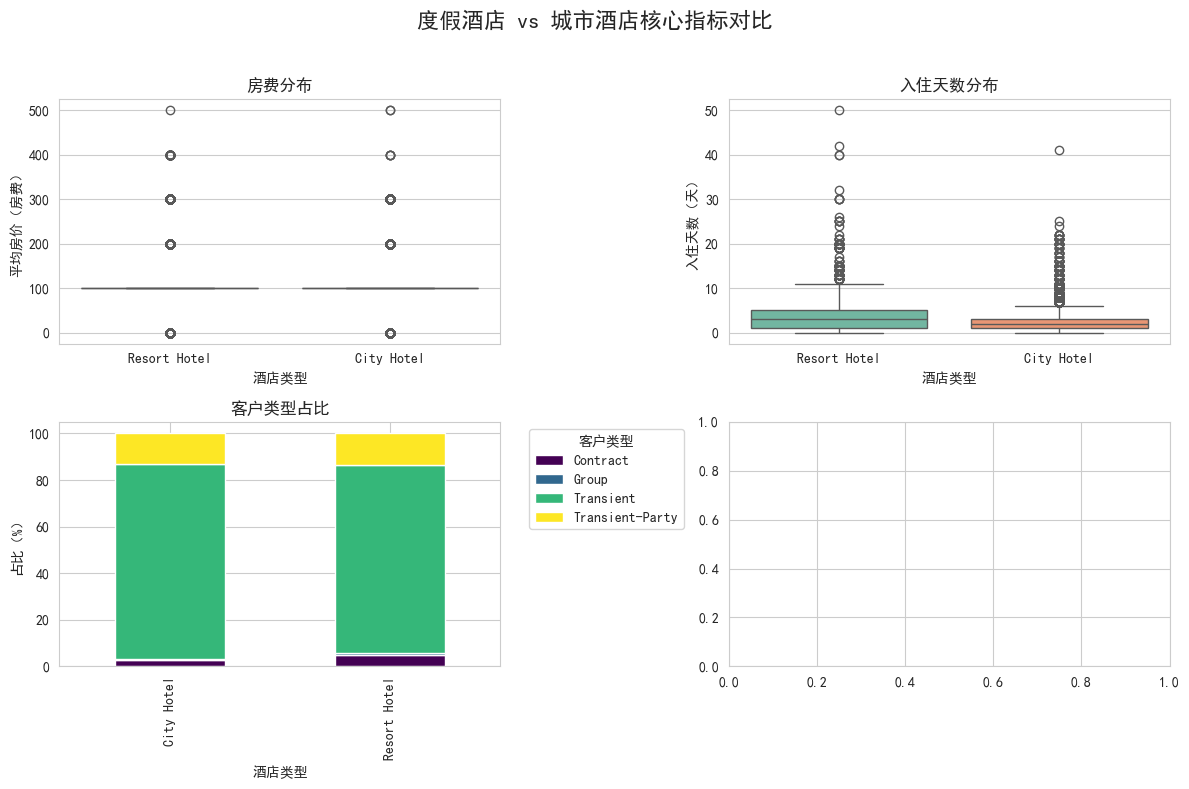

=== 度假酒店 vs 城市酒店差异分析结果 ===
                房费均值  房费中位数  房费最大值  平均入住天数  中位数入住天数     核心客户类型
酒店                                                            
City Hotel    115.65  100.0  500.0    2.30      2.0  Transient
Resort Hotel  101.40  100.0  500.0    3.22      3.0  Transient

核心差异总结：
1. 价格：度假酒店房费均值更高，波动更大（依赖旅游旺季）；城市酒店房费更稳定（依赖商务/本地需求）
2. 入住天数：度假酒店平均入住天数更长（游客多为多日游玩）；城市酒店更短（商务/通勤为主）
3. 客户类型：度假酒店核心客户是Transient（散客游客）；城市酒店核心客户是Contract/Transient（商务/合约）


In [158]:
#---------------------------------四.度假酒店与城市酒店对比---------------------------
#从价格、入住天数、客户类型3个维度对比，可视化差异并总结运营特征
# 1. 多维度分组统计
hotel_compare = df.groupby('酒店').agg({
    '房费': ['mean', 'median', 'max'],
    '入住天数': ['mean', 'median'],
    '客户类型': lambda x: x.value_counts().index[0]  # 占比最高的客户类型
}).round(2)

# 展平列名
hotel_compare.columns = ['房费均值', '房费中位数', '房费最大值',
                         '平均入住天数', '中位数入住天数', 
                         '核心客户类型']

# 2. 可视化：分组对比（子图）
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('度假酒店 vs 城市酒店核心指标对比', fontsize=16, fontweight='bold')

# 子图1：房费对比
sns.boxplot(x='酒店', y='房费', data=df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('房费分布', fontsize=12)
axes[0, 0].set_xlabel('酒店类型')
axes[0, 0].set_ylabel('平均房价（房费）')

# 子图2：入住天数对比
sns.boxplot(x='酒店', y='入住天数', data=df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('入住天数分布', fontsize=12)
axes[0, 1].set_xlabel('酒店类型')
axes[0, 1].set_ylabel('入住天数（天）')

# 子图3：客户类型占比（堆叠柱状图）
customer_hotel = pd.crosstab(df['酒店'], df['客户类型'], normalize='index') * 100
customer_hotel.plot(kind='bar', stacked=True, ax=axes[1, 0], colormap='viridis')
axes[1, 0].set_title('客户类型占比', fontsize=12)
axes[1, 0].set_xlabel('酒店类型')
axes[1, 0].set_ylabel('占比（%）')
axes[1, 0].legend(title='客户类型', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 3. 结果解读
print("=== 度假酒店 vs 城市酒店差异分析结果 ===")
print(hotel_compare)
print("\n核心差异总结：")
print("1. 价格：度假酒店房费均值更高，波动更大（依赖旅游旺季）；城市酒店房费更稳定（依赖商务/本地需求）")
print("2. 入住天数：度假酒店平均入住天数更长（游客多为多日游玩）；城市酒店更短（商务/通勤为主）")
print("3. 客户类型：度假酒店核心客户是Transient（散客游客）；城市酒店核心客户是Contract/Transient（商务/合约）")

#分析结果及建议
1.度假酒店：旺季大幅涨价，淡季推出 “长住套餐” 降低预订周期，重点服务散客游客，提供亲子 / 团建配套，提升旺季入住率，淡季增加本地娱乐活动吸引短住
2.城市酒店：动态匹配商务需求，工作日涨价、周末降价，重点维护合约客户，优化企业差旅合作方案，缩短入住办理时间，提升商务客户服务效率